# Clase No Supervisado

## Maldición de la Dimensionalidad

Los algoritmos que implementamos operan en un número finito de dimensiones que se establecenen  una  serie de  espacios $d$-dimensionales. En  la  medida que  esta cantidad de  dimensiones aumenta, el desempeño de los algoritmos empeorará. Este fenómeno se conoce como la maldición de la dimensionalidad.El problema es que la convergencia de cualquier estimador al parámetro verdadero de una función definida en  un  espacio $d$-dimensional es  muy lento dado al  exceso de  atributos y  falta de observaciones. Ejemplifiquemos la  distancia entre puntos cuando aumentamos la  cantidad dedimensiones. Para ello implementamos la función `sim_distance`. La función simula una serie finita de 1000 puntos aleatorios en un cubo y estima sus distancias. Evaluaremos la  función cuando tenemos 2,  10,  100  y  1000 atributos. La  función retorna unhistograma de  la  distancia y  la  recta roja  señala la  media de  la  distancia. En  la  medida que aumentamos artificalmente la  cantidad de  dimensiones, la  distancia promedio entre dos  puntos aumenta substancialmente. Esto genera problemas de  estimación y  de  velocidad  en  las computaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import seaborn as sns
import lec7_graphs as gfx
import warnings
warnings.filterwarnings(action="ignore")

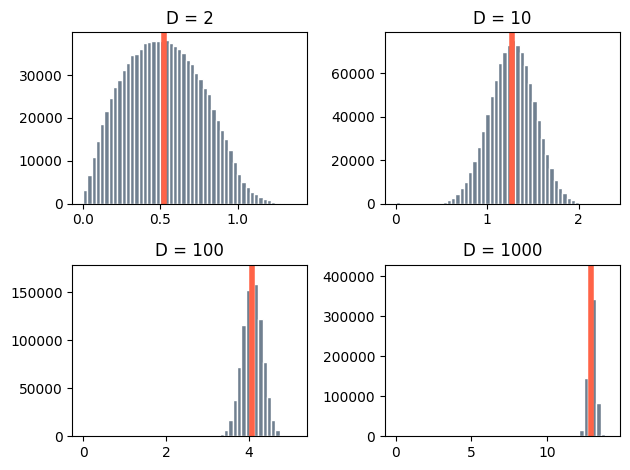

In [2]:
for i, e in enumerate([2, 10, 100, 1000]):
    plt.subplot(2,2, i+1)
    gfx.sim_distance(e)
    plt.tight_layout()

### Digresión: Bendiciones de la dimensionalidad

No todo lo asociado con la dimensionalidad es negativo. Donoho (2000) sugiere que un problema a investigar con más dimensiones que observaciones permite concentrar las mediciones en dimensiones que capturen distintos aspectos de los atributos. Esta nueva proyección será
constante en el espacio de los datos, la distancia promedio entre dos puntos tiende a aumentar substancialmente.

Este aumento de la distancia conlleva a las matrices dispersas, asociadas a problemas computacionales.

Las representaciones y distribuciones dispersas son un tema de amplio estudio en machine learning y deep learning ya que permiten agilizar los cálculos computacionales y debido al alto ruido que suelen presentar, aumentan la correlación entre los atributo. Se sabe que algunas redes neuronales pueden verse beneficiadas con el ruido en los atributos.

## ¿Y cómo resolvemos el problema de la dimensionalidad?

Existen dos escuelas de análisis frente a la dimensionalidad. Una escuela psicométrica, enfocada en la identificación de "factores causales" condicionales a un conjunto $d>>n$ de datos. La otra escuela, más cercana a las ciencias de la computación busca redimensionar los factores latentes mediante la maximización de la varianza.

## Análisis Factorial: La visión psicométrica

El análisis factorial busca extraer información sobre la variabilidad de conjunto finito de variables, y transformarla en una serie de factores latentes (o no-observables empíricamente). Para ello, el análisis busca la variación conjunta de dos variables en respuesta a un factor específico. Las variables observadas se modelan como una combinaciónn lineal de los factores y errores.

Si deseamos analizar cómo una serie de variables observadas $X$ están asociadas de forma lineal a una cantidad finita de factores $f$, empleamos el siguiente sistema de ecuaciones

$$X_1 = \lambda_{10} + \lambda_{11}F_1 \cdots + \lambda_{1k}F_k + \epsilon_1$$
$$X_2 = \lambda_{20} + \lambda_{21}F_1 \cdots + \lambda_{2k}F_k + \epsilon_2$$
$$\vdots$$
$$X_n = \lambda_{n0} + \lambda_{n1}F_1 \cdots + \lambda_{nk}F_k + \epsilon_n$$

donde $\lambda$ representa la carga asociada a la combinación lineal y $\epsilon$ representa el error en la medición del constructo.

## Implementando un análisis de factores con `factor_analyzer`

A lo largo de esta sección, trabajaremos con una encuesta del Centro de Estudios Públicos realizada en Junio del 2003. Parte de la batería de preguntas está asociada a preguntas sobre el nivel de confianza institucional.

Las preguntas se refieren la evaluación en una serie de instituciones de la sociedad civil, tales como:

- `p17_a` : La Iglesia Católica.
- `p17_b` : La Iglesia Evangélica.
- `p17_c` : Las Fuerzas Armadas.
- `p17_d` : Los Tribunales de Justicia.
- `p17_e` : La Prensa Escrita.
- `p17_f` : La Televisión.
- `p17_g` : Los Sindicatos.
- `p17_h` : Los Carabineros.
- `p17_i` : El Gobierno.
- `p17_j` : Los Partidos Políticos.
- `p17_k` : El Congreso.
- `p17_l` : Las Empresas.
- `p17_m` : Las Universidades.
- `p17_n` : La Radio.

Cada una de éstas preguntas se evalúo en una escala entre 1 (Mucha Confianza), 2 (Bastante Confianza), 3 (No Mucha Confianza), 4 (Ninguna Confianza). Las categorías 8 (No sabe), 9 (No contesta) representan valores perdidos.

Para implementar un análisis factorial en Python, utilizaremos la librería `factor_analyzer`.

### Digresión: Estandarizando un conjunto de variables

Ante la eventualidad de estandarizar, la opción más viable es mapear una función a lo largo del conjunto de variables. Esto se puede lograr con:

```python
df.loc[:, 'conjunto':'variables'].applymap(lambda x: stats.zscore(x))
```

Importemos la base de datos:

In [3]:
import factor_analyzer as factor
import missingno as msngo

df = pd.read_csv('cep45.csv')

Nuestro objetivo es preprocesar y analizar la batería de preguntas asociadas a la confianza institucional. Para ello nos enfocaremos en el comportamiento empírico de las variables y en las tasas de valores perdidos.

Dado que trabajaremos de manera reiterada con este conjunto, una buena práctica es separarlo en un nuevo objeto. Ya sabemos cómo segmentar columnas con `loc`, ahora lo haremos con `filter`. Dentro de los argumentos de `filter` implementaremos la opción `regex`, que emplea expresiones regulares para encontrar patrones comunes entre strings. Para este caso emplearemos un asterisco como comodín.

Con nuestra batería seleccionada, grafiquemos el comportamiento de las respuestas utilizando `items()` como un orientador del loop. Se observa que a lo largo de todas las preguntas las tasas de no respuesta son bajas, no superando el 1% del total de las observaciones,

In [4]:
df.head()

,corr,filtro,psu,region,p1_1,p1_2,p1_3,p2,p3,p4,...,de14_b,de14_c,de14_d,de14_e,de14_f,de15,de16,de17,b5,pond
0,1,937,150,13,9,3,6,1,3,2,...,2,2,2,2,2,6,4,4,1,0.782461
1,2,938,150,13,7,6,3,2,2,1,...,2,2,1,2,2,8,4,4,1,1.157864
2,3,939,150,13,3,6,9,2,2,3,...,2,2,2,2,2,9,6,4,1,1.204037
3,4,1096,182,13,3,4,11,3,2,2,...,2,2,2,2,2,6,3,3,1,1.025330
4,5,1097,182,13,6,11,7,3,1,1,...,2,2,2,2,2,6,3,3,1,1.204037


In [5]:
df.describe()

,corr,filtro,psu,region,p1_1,p1_2,p1_3,p2,p3,p4,...,de14_b,de14_c,de14_d,de14_e,de14_f,de15,de16,de17,b5,pond
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,...,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,752.000000,753.267465,150.953426,9.187625,6.913506,7.504325,7.936793,2.489022,2.048570,1.913506,...,2.131071,2.108450,1.924817,2.064538,2.137725,18.617432,4.061876,3.489687,1.139055,1.000000
std,434.023041,434.827153,86.900408,3.747622,4.805730,5.853273,6.943705,0.899611,1.372998,1.258462,...,0.984967,0.999108,1.089993,1.024578,0.999498,30.589297,2.053098,0.837531,0.346119,0.189577
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.659186
25%,376.500000,376.500000,76.000000,6.000000,3.000000,5.000000,5.000000,2.000000,1.000000,1.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,5.000000,3.000000,3.000000,1.000000,0.782461
50%,752.000000,754.000000,151.000000,9.000000,6.000000,7.000000,7.000000,3.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,7.000000,4.000000,4.000000,1.000000,1.037718
75%,1127.500000,1129.500000,226.000000,13.000000,10.000000,10.000000,10.000000,3.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,10.500000,5.000000,4.000000,1.000000,1.157864
max,1503.000000,1505.000000,301.000000,13.000000,99.000000,99.000000,99.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,99.000000,17.000000,5.000000,2.000000,1.446977


In [6]:
# filtamos las columnas
trust_df = df.filter(regex="p17_*")
trust_df = trust_df.rename(columns={'p17_a': 'I.Catolica', 'p17_b': 'I.Evangelica', 'p17_c': 'FFAA', 'p17_d': 'Justicia', 'p17_e': 'Prensa', 'p17_f': 'Television', 'p17_g':'Sindicatos', 'p17_h':'Carabineros', 'p17_i': 'Gobierno', 'p17_j': 'PartidosPol', 'p17_k': 'Congreso', 'p17_l':'Empresas', 'p17_m':'Universidades', 'p17_n':'Radio'})

In [7]:
def fetch_missing(df, missing_vals):
    for colname, serie in df.items():
        print(colname, serie.isin(missing_vals).value_counts('%')[1].round(2))
        
fetch_missing(trust_df, missing_vals=[8, 9])

I.Catolica 0.03
I.Evangelica 0.07
FFAA 0.04
Justicia 0.04
Prensa 0.03
Television 0.02
Sindicatos 0.09
Carabineros 0.02
Gobierno 0.03
PartidosPol 0.03
Congreso 0.05
Empresas 0.04
Universidades 0.07
Radio 0.03


La función `matrix` dentro de la librería `missingno` permite visualizar la matriz de datos, las líneas en blanco representan respuestas perdidas (o negadas) por el encuestado. De manera similar a lo entregado por nuestra función fetch_missing , las preguntas con mayores niveles de perdidos son `p17_b` (La Iglesia Evangélica), `p17_g` (Los Sindicatos), `p17_m` (Las Universidades). 

Esperamos que éstas variables presenten cargas bajas en los factores. Este punto será retomado posteriormente

<Figure size 400x400 with 0 Axes>

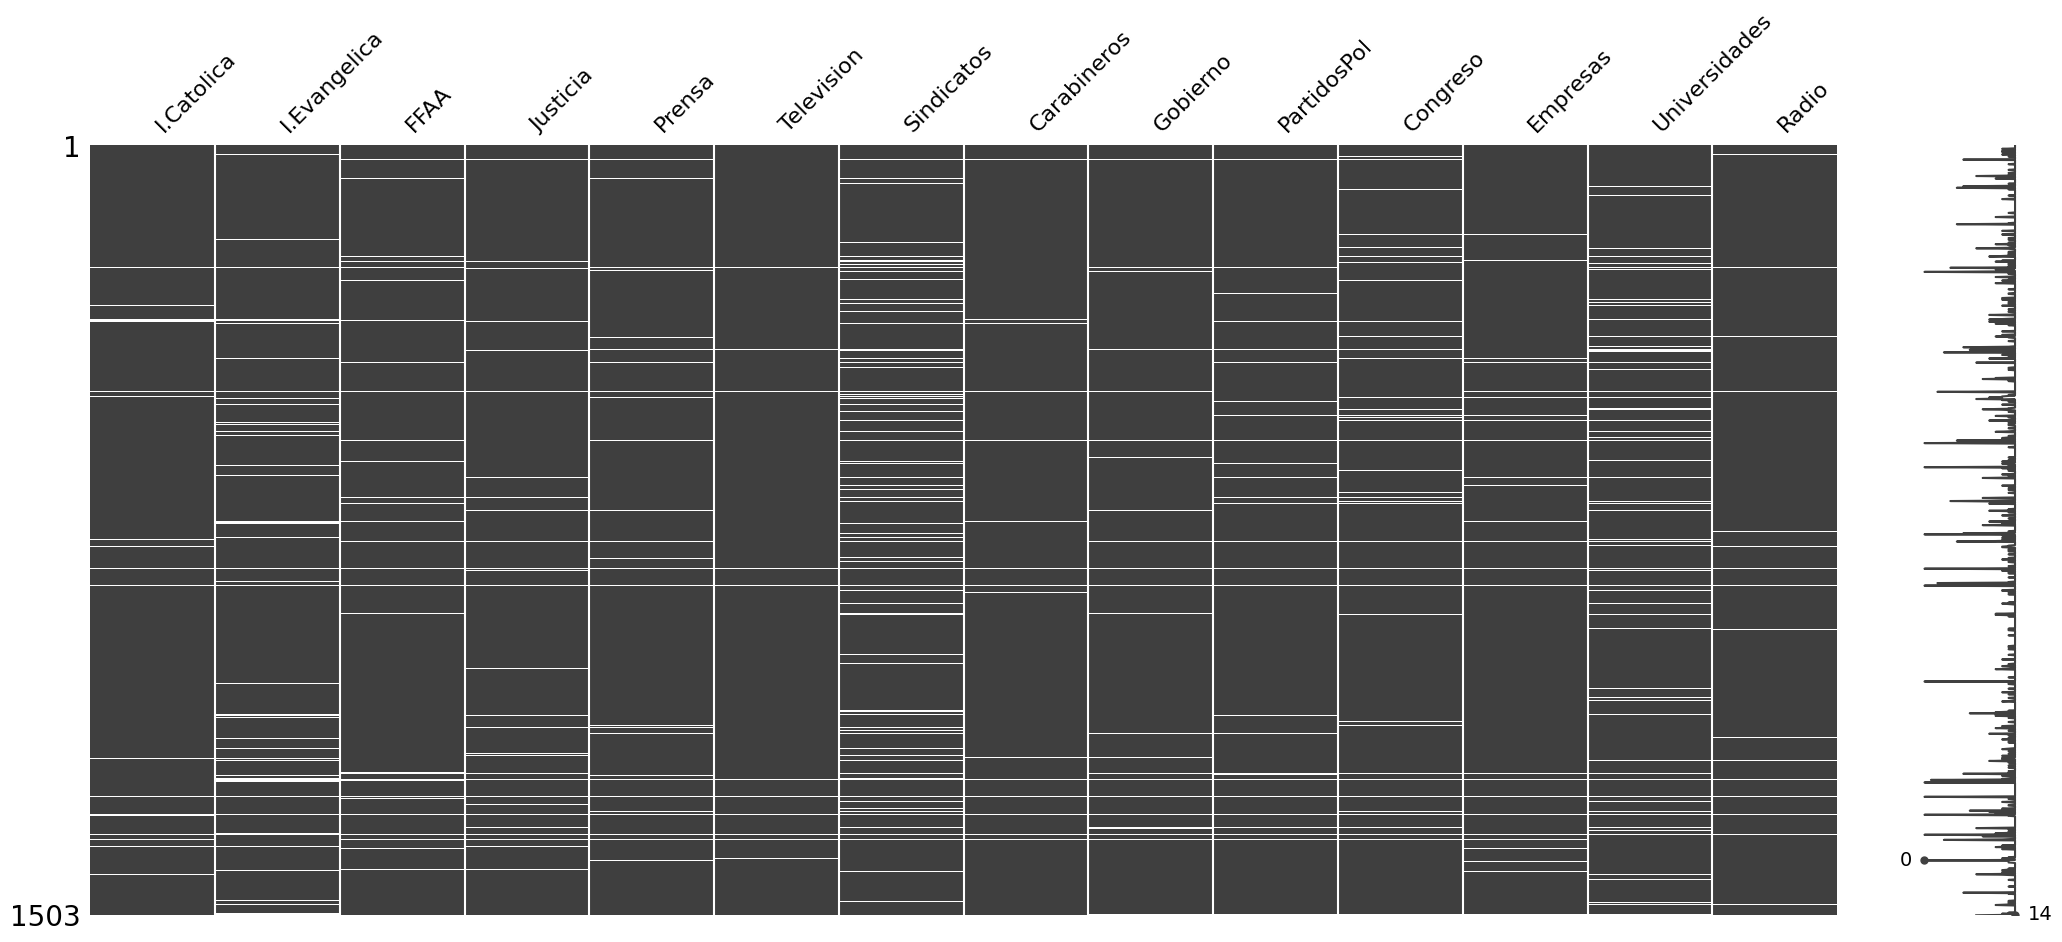

In [8]:
plt.figure(figsize=(4,4))
msngo.matrix(trust_df.replace([8, 9], [np.nan, np.nan]));

Una vez analizado el patrón de datos perdidos, optamos por eliminarlos y procedemos con inspeccionar las medias de cada variable en la batería de preguntas mediante un dotplot.

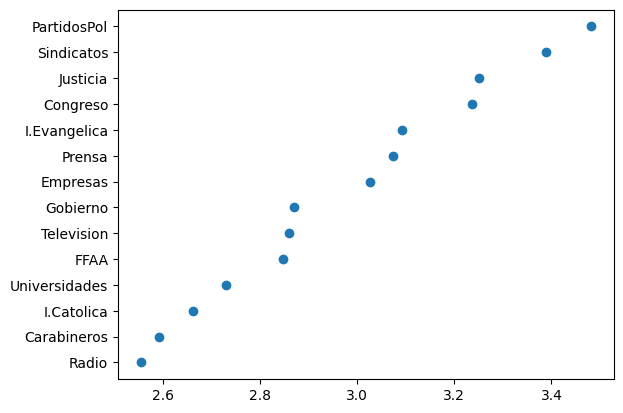

In [9]:
# Generamos dos arrays vacíos para guardar el nombre de la variable y la media
variable = []
mean = []
# para cada columna de la base, extraemos su nombre y sus valores
for colname, serie in trust_df.items():
    # guardamos el nombre en variable
    variable.append(colname)
    # calculamos y procesamos la media
    mean.append(serie.mean())
    
df = pd.DataFrame({'var':variable, 'mean': mean}).sort_values(by=['mean'])
plt.plot(df['mean'], df['var'],'o')

Recordemos que valores más altos en la escala de confianza significa que la sociedad confía menos en las instituciones. En un extremo observamos a instituciones de carácter político como los Partidos Políticos, los Tribunales de Justicia, el Congreso y los Sindicatos.

En el otro extremo encontramos a instituciones "cotidianas", aquellas que presentan un mayor grado de interacción con las personas como los Carabineros, la Iglesia Católica y la Radio. Esto entrega indicios sobre dos grupos de instituciones.

Antes de modelar los factores latentes de nuestro modelo, es necesario realizar un par de pruebas sobre la ideonidad de nuestra matriz de datos para extraer factores. Las pruebas de esferacidad de Barlett y de muestreo de Kaiser-Meyer-Olkin entregan información sobre la existencia de covarianza entre variables en la batería de preguntas. Si nos encontramos ante casos donde las cargas en la matriz de covarianza son bajas y/o responden a otras estructuras de datos, es preferible implementar otros enfoques que escapan a los objetivos del curso.

## Prueba de esferacidad de errores de Bartlett

Con nuestra matriz de factores estimada, ahora debemos preguntarnos si nuestra matriz de correlaciones está relacionada con una matriz de identidad (matriz donde la diagonal principal es de 1 y los triángulos superiores e inferiores son 0).

De manera similar a las otras pruebas de estadísticos de ajuste, si encontramos evidencia para fallar en rechazar la hipótesis nula, la prueba concluye que la matriz sigue una distribución multivariada normal no sigue una matriz de identidad, por lo que se puede proceder con el análisis de factores.

Para implementar la prueba dentro de `Python`, utilizamos el método `calculate_bartlett_sphericity` de la librería `factor_analyzer` en nuestra batería de preguntas. La prueba retorna un puntaje `chi-square` de la distribución y un `p-value` asociado a esa prueba. En este caso, la prueba de esferacidad de errores sugiere que la matriz de correlaciones no es igual a la matriz de identidad, por lo que se puede seguir con el análisis.

In [10]:
import factor_analyzer as fact

In [11]:
fact.calculate_bartlett_sphericity(trust_df)

(np.float64(6630.891612219095), np.float64(0.0))

## Prueba de muestreo Kaiser-Meyer-Olkin (KMO)

De manera adicional a la prueba de Bartlett, podemos medir si las correlaciones parciales dentro de la matriz son cercanas a 0. De ser este el caso, la prueba sugiere la existencia de por lo menos un factor latente dentro de la batería de preguntas.

Se puede implementar mediante el método `calculate_kmo` de la librería `factor_analyzer`. El método devuelve el puntaje KMO para cada item dentro de la batería, así como un puntaje global para todos los items.

Se sugiere que para seguir con el análisis factorial, el KMO debe presentar valores superiores a .7. En este caso se satisface el punto y podemos proseguir.

Ante el caso en que encontremos puntajes bajos, la estructura a estimar se puede mejorar al eliminar los items con cargas KMO inferiores al puntaje de corte.

La eliminación de éstos items permite liberar la matriz de elementos inestables que dificulten la identificación de los factores a extraer.

In [12]:
fact.calculate_kmo(trust_df)

(array([0.93861106, 0.92726637, 0.93185239, 0.9529143 , 0.91981398,
        0.88566125, 0.93679868, 0.9113125 , 0.93989144, 0.91301888,
        0.91937924, 0.94242112, 0.95184539, 0.93229633]),
 np.float64(0.9275552166414566))

## Estimando la cantidad de factores a extraer

Posterior al análisis de la ideonidad de nuestra matriz de datos para el análisis factorial, la siguiente pregunta a responder es ¿qué tantos factores necesitamos?

Para ello podemos analizar los valores propios (eigenvalues) de la decomposición de la matriz. Estos informan qué tanta varianza se puede atribuir un factor en específico. Mediante la definición de qué tantos factores necesitamos para caracterizar una matriz podemos obtener una estructura parsimoniosa e interpretable.

La manera más simple de analizar esto es mediate un scree plot, que visualiza los eigenvalues en la medida que se aumenta la cantidad de factores. Por convención no pueden existir más factores que variables dentro de la matriz.

Comencemos por implementar un modelo con factor_analyzer . 

   - Nuestro objeto instanciado, podemos implementar en análisis con `factorize.analyze`. El primer parámetro (`data`) que debe ser ingresado es la matriz a decomponer. El segundo parámetro (`n_factors`) es la cantidad de factores a extraer. Por último, `method` hace referencia a la rotación aplicada en la matriz de cargas. Implementaremos la estrategia más simple conocida como `varimax`.
   - Con las cargas $\lambda$ podemos estimar una matriz $\Lambda$ de covarianza para calcular la matriz de covarianza **observable**. Asumiendo cumplimiento de los supuestos, se asume que $\Lambda$ es un buen aproximado de la covarianza **observable**.
   -  Por lo general empleamos Análisis de Componentes Principales para estimar la comunalidad total de la matriz.
   -  Las cargas $\lambda$ no tienen una identificación única, por lo que se puede emplear una "rotación" de la matriz para encontrar una mejor estructura latente. Están los métodos ortogonales (que no permiten correlación entre factores) y oblicuos (que sí permiten correlación entre factores). Algunas de las más utilizadas son:
       -  Varimax: rotación que busca maximizar la varianza de las cargas para cada factor.
       -  Quartimax: rotación que busca maximizar la varianza de las cargas y tiende a producir cargas más altas para cada variable.
   - Para generar el scree plot, extraemos los eigenvalues reportados en `factorize.get_eigenvalues()[0]` y los graficamos contra la cantidad de factores estimables.

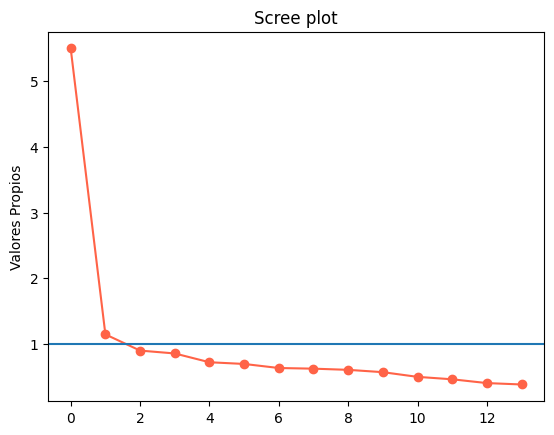

In [13]:
# Compatibilidad factor_analyzer con sklearn >= 1.6
import inspect
from sklearn.utils import validation as sk_validation
import factor_analyzer.factor_analyzer as fa_mod

if 'force_all_finite' not in inspect.signature(sk_validation.check_array).parameters:
    def _check_array_compat(*args, **kwargs):
        if 'force_all_finite' in kwargs and 'ensure_all_finite' not in kwargs:
            kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
        return sk_validation.check_array(*args, **kwargs)
    fa_mod.check_array = _check_array_compat

# Generamos una nueva instancia en el objeto factorize
factorize = fact.FactorAnalyzer(n_factors=2, rotation='varimax')
factorize.fit(trust_df)
# extraemos los eigenvalues
factor_screeplot = factorize.get_eigenvalues()[0]
# graficamos los eigenvalues contra la cantidad de dimensiones estimables
plt.plot(factor_screeplot, 'o-', color='tomato')
plt.ylabel('Valores Propios')
# visualizamos el criterio de corte
plt.axhline(1)
plt.title("Scree plot");

A modo de guía: Un factor con valor propio de **exactamente 1** significa que ese factor explica una parte de la varianza igual a la de una variable, de forma análoga, un factor con valor propio mayor/menor a 1 explica una varianza total mayor/menor a la de una sola variable.

La convención indica que se deben preservar todos los factores con eigenvalues mayores a 1. De esta forma maximizamos la cantidad de varianza explicada por la matriz. Los resultados indican que hay 2 dimensiones substanciales.

## Digresión: Sobre los criterios de elección del número de factores

Si bien en esta ocasión utilizamos el valor propio de los factores como criterio de selección, cabe destacar que no existe una regla clara a la hora de escoger la cantidad de factores a preservar y todo depende de lo que veamos en el gráfico, por ejemplo, otra regla común para esta tarea es fijarse en el 'codo' de la curva en el scree plot, si nos fijamos, la curva parece disminuir la pendiende a valores cercanos a 0 en el factor 3, por lo que podemos tomar ese punto como límite para los factores con los que nos quedaremos, en este caso, con los factores 1 y 2.

## Extracción e interpretación de los factores

La evidencia apunta que nuestro modelo está correctamente especificado, y tenemos 2 grandes dimensiones no observables. Para extraer los resultados sobre qué preguntas están asociadas entre sí, podemos solicitar las cargas $\lambda$ en cada factor con `factorize.loading_`.

In [14]:
loading_array = factorize.loadings_

factor_loadings = pd.DataFrame(loading_array, index=trust_df.columns)
factor_loadings.columns = ['Factor1', 'Factor2']
factor_loadings

,Factor1,Factor2
I.Catolica,0.211538,0.482076
I.Evangelica,0.189092,0.315560
FFAA,0.446360,0.441059
Justicia,0.495019,0.369861
Prensa,0.392996,0.506117
Television,0.208389,0.700067
Sindicatos,0.508384,0.183166
Carabineros,0.249729,0.568515
Gobierno,0.513112,0.457081
PartidosPol,0.666885,0.288312


La información presentada en la matriz no es muy clara. Emplearemos un par de métodos para simplificar su interpretación:

1. El método `applymap` permite aplicar una función a una serie de columnas. En este caso implementaremos una función `lambda` en ambas columnas.
2. El primer elemento a emplear es el reemplazar los valores con un string vacío cuando sus cargas sean menores a .4. La lógica de excluir cargas menores es limpiar cargas bajas con cada factor y simplificar la estructura. Esto lo logramos con `np.where`.
3. El segundo elemento es redondear las cargas en aquellos elementos substanciales con `round`.

In [15]:
factor_loadings.applymap(lambda x: ' ' if x < .4 else round(x, 2))

,Factor1,Factor2
I.Catolica,,0.48
I.Evangelica,,
FFAA,0.45,0.44
Justicia,0.5,
Prensa,,0.51
Television,,0.7
Sindicatos,0.51,
Carabineros,,0.57
Gobierno,0.51,0.46
PartidosPol,0.67,


Las cargas señalan que el Factor 1 se compone de instituciones explícitamente políticas, donde destacan el Poder Judicial, los Sindicatos, El Gobierno, Los Partidos Políticos, el Congreso, las Empresas y Universidades. Este factor se puede denominar como confianza en los elementos más
políticos de las instituciones.

El Factor 2 presenta cargas altas asociadas a la Iglesia Católica, Prensa, Televisión, Carabineros y Radio. A diferencia del primer factor, en éste predominan los elementos más cotidianos de la sociedad. Estas son las instituciones con las cuales se interactúa de una manera más frecuente. 

Ambos factores están asociados y se pueden presentar en un diagrama de dispersión. Este muestra que ambos se sitúan en una relación inversa. Valores más altos en el Factor 1 están asociados a valores bajos en el Factor 2.

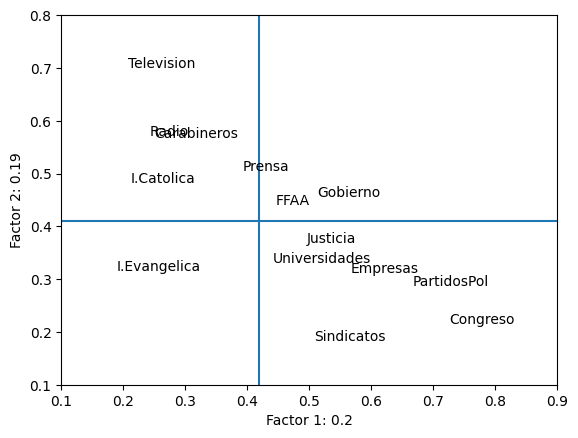

In [16]:
# guardemos la varianza explicada por cada dimensión
factor_var_array = factorize.get_factor_variance()
factor_var = pd.DataFrame(factor_var_array, index=['SS Loadings', 'Proportion Var', 'Cumulative Var'])
factor_var.columns = ['Factor1', 'Factor2']
# cruzamos ambos factores
plt.plot(factor_loadings.Factor1, factor_loadings.Factor2,'o',color='white')
plt.xlim((0.1, 0.9)) # definimos límites
plt.ylim((0.1, 0.8))
# Para cada elemento en los factores
for i, txt in enumerate(factor_loadings.index):
    # anotemos el nombre de la variable
    plt.annotate(txt, (factor_loadings['Factor1'][i], factor_loadings['Factor2'][i]))
# Grafiquemos la media de ambos factores
plt.axvline(factor_loadings['Factor1'].mean())
plt.axhline(factor_loadings['Factor2'].mean())
# Reportemos la varianza de cada dimensión
plt.xlabel('Factor 1: {}'.format(round(factor_var['Factor1'][1], 2)))
plt.ylabel('Factor 2: {}'.format(round(factor_var['Factor2'][1], 2)))
plt.show()

## Extracción de puntajes

Cada factor se presentaba como la combinación lineal entre las cargas y las respuestas de cada item. Como tal, se pueden extraer los puntajes estimados entre ambos elementos mediante el método get_scores para cada factor generado.

Éstos puntajes vienen dados por la estandarización de los factores, por lo que tendrán una distribución $\widetilde{X} \sim N(0,\sigma^2)$.

Los puntajes pueden ser utilizado posteriormente en modelos predictivos como variables dependientes y/o independientes, así como en la creación y construcción de índices compuestos.

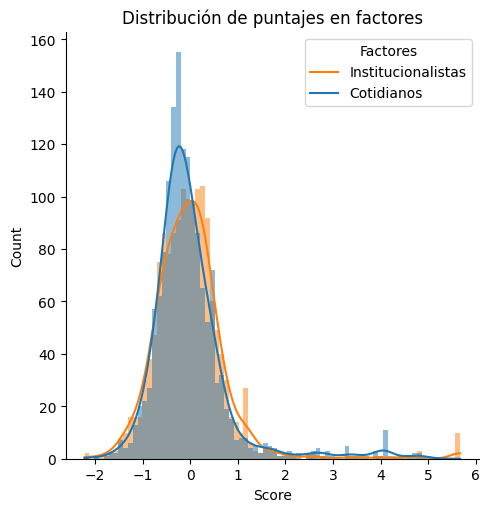

In [17]:
extract_factor_scores_array = factorize.transform(trust_df)
extract_factor_scores = pd.DataFrame(extract_factor_scores_array, columns=['Factor1', 'Factor2'])

extract_factor_scores_long = extract_factor_scores.melt(var_name='Factor', value_name='Score')

sns.displot(extract_factor_scores_long, x='Score', hue='Factor', kind='hist', kde=True, edgecolor=None, legend=False)

plt.legend(title='Factores', labels=['Institucionalistas', 'Cotidianos'])
plt.title('Distribución de puntajes en factores')
plt.show()